In [1]:
%load_ext autoreload
%autoreload 2

# SPY Trend Following Study

## General Theory

- We identify trends by from the volatility and $R^2$ value of the linear regression of log(close).
- We use various indicators to forecast the `trend_value = mean_return * vol * r2`
- Trade according to the trend value.


## Libraries

In [26]:
import pandas as pd
import numpy as np
from utils.backtester import BackTester
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from utils.data_fetcher import YahooDataFetcher
import datetime
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

## Data Loading

In [37]:
# Current date
current_date = datetime.datetime.now().date()
current_date = current_date.strftime("%Y%m%d")
print(current_date)

# Fetch daily price data from Yahoo Finance
fetcher = YahooDataFetcher()
ticker_list = ['SPY', '^VIX']
fetcher.load_price_data(tickers=ticker_list)

ticker = "SPY"
df_raw = pd.read_pickle(f'data/raw/price/{ticker}_{current_date}.pkl') 

INFO:utils.data_fetcher:Fetching data for SPY with yfinance


20250316


INFO:utils.data_fetcher:Moved SPY_20250315.pkl to archive
INFO:utils.data_fetcher:Fetching data for ^VIX with yfinance
INFO:utils.data_fetcher:Moved ^VIX_20250315.pkl to archive


## Data Preparation

### Dependent variables
- forward mean return (21-days)
- forward vol (21-days)
- r_2 of linear regression of forward close prices

In [34]:
def calc_forward_returns(df, col='forward_returns', period=21):
    """
    Calculate forward returns given dataframe with close prices and period
    """
    df = df.copy()
    df['temp_returns'] = df['close'].rolling(period).apply(lambda x: (x[-1] - x[0]) / x[0])
    df[col] = df['temp_returns'].shift(-period)
    df.drop('temp_returns', axis=1, inplace=True)
    return df

def calc_forward_vol(df, col='forward_vol', period=21):
    """
    Calculate forward volatility given dataframe with close prices and period
    """
    df = df.copy()
    df['temp_ret'] = df['close'].pct_change()
    df['temp_vol'] = df['temp_ret'].rolling(period).apply(lambda x: np.std(x))
    df[col] = df['temp_vol'].shift(-period)
    df.drop(['temp_vol', 'temp_ret'], axis=1, inplace=True)
    return df

def calc_r2(df, col='r2', period=21):
    """
    Calculate R2 given dataframe with close prices and period
    """
    df = df.copy()
    r2_arr = []
    for i in range(df.shape[0]):
        if i + period >= df.shape[0]:
           r2_arr.append(np.nan)
        else:
            # r2 is the R2 error term for a linear regression of log prices
            # We fit a linear regression of the log prices over unit time and then calculate the R2 with sklearn r2_score
            # R2 denotes how closely the log prices follow a linear trend
            close_prices_arr = df[i:i+period]['close'].to_numpy()
            log_prices_arr = np.log(close_prices_arr)
            model = LinearRegression()
            model.fit(np.arange(period).reshape(-1, 1), log_prices_arr)
            r2 = r2_score(log_prices_arr, model.predict(np.arange(period).reshape(-1, 1)))
            r2_arr.append(r2)
    
    df[col] = r2_arr
    return df

def calc_trend_value(df):
    """
    Calculate custom indicator trend_value given dataframe
    Requires dataframe to have the following columns:
    - forward_returns
    - forward_vol
    - r2

    Use standard scaler to scale trend_value to standard normal distribution
    Returns the standard scaler as well to scale new values
    """
    df = df.copy()
    trend_value = df['forward_returns'] / df['forward_vol'] * df['r2']
    # Create a StandardScaler object
    scaler = StandardScaler()

    # Fit the scaler to the data and transform the data
    scaled_data = scaler.fit_transform(trend_value.values.reshape(-1, 1))
    df['trend_value'] = scaled_data
    return df, scaler



df_data = df_raw.copy()
df_data = calc_forward_returns(df_data)
df_data = calc_forward_vol(df_data)
df_data = calc_r2(df_data)
df_data, trend_value_scaler = calc_trend_value(df_data)
df_data

,open,high,low,close,adjclose,volume,dividends,stock_splits,capital_gains,forward_returns,forward_vol,r2,trend_value
Date,,,,,,,,,,,,,
1993-01-29,43.968750,43.968750,43.750000,43.937500,24.526064,1003200,0.0,0.0,0.0,0.015537,0.008034,0.150948,-0.280482
1993-02-01,43.968750,44.250000,43.968750,44.250000,24.700508,480500,0.0,0.0,0.0,0.017618,0.007953,0.114169,-0.292468
1993-02-02,44.218750,44.375000,44.125000,44.343750,24.752850,201300,0.0,0.0,0.0,0.001395,0.008067,0.050267,-0.367505
1993-02-03,44.406250,44.843750,44.375000,44.812500,25.014503,529400,0.0,0.0,0.0,-0.005556,0.007777,0.023704,-0.375378
1993-02-04,44.968750,45.093750,44.468750,45.000000,25.119165,531500,0.0,0.0,0.0,0.017373,0.009096,0.001823,-0.369105
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-10,567.590027,569.539978,555.590027,560.580017,560.580017,99326600,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2025-03-11,559.400024,564.020020,552.020020,555.919983,555.919983,88102100,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2025-03-12,562.169983,563.109985,553.690002,558.869995,558.869995,69588200,0.0,0.0,0.0,NaN,NaN,NaN,NaN


#### Histograms

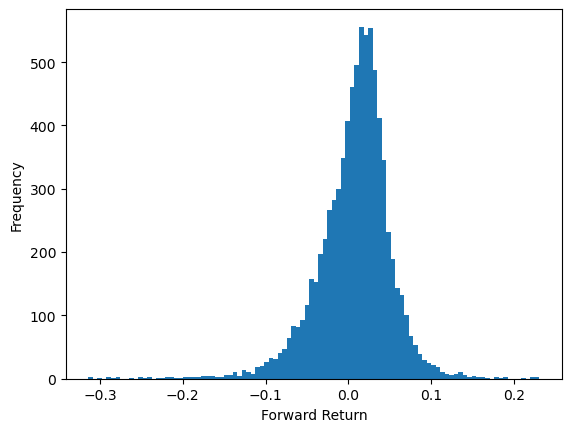

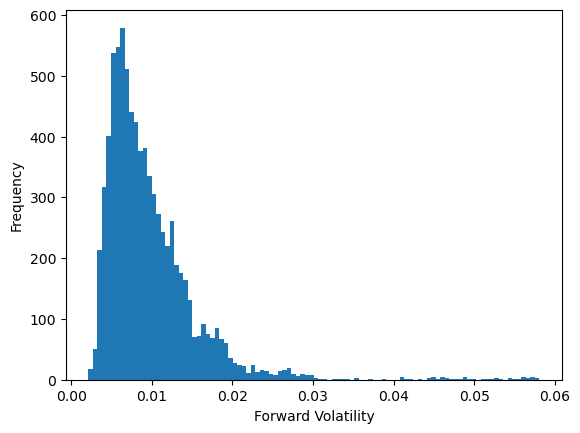

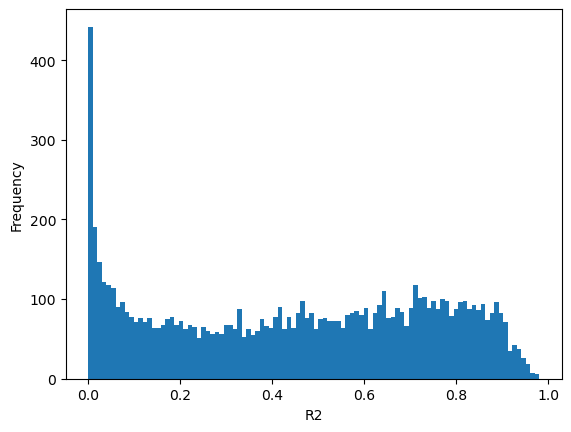

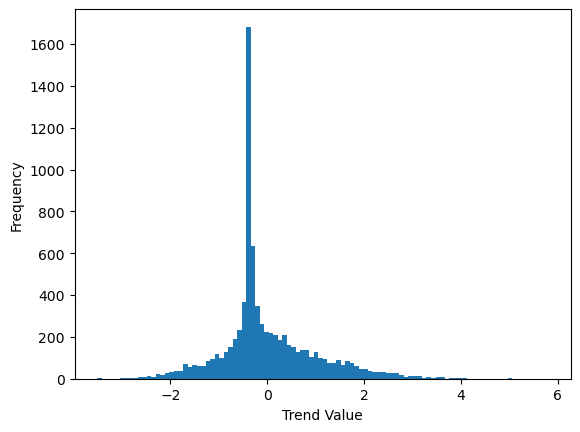

In [36]:
# Forward returns
plt.hist(df_data['forward_returns'], bins=100)
plt.xlabel('Forward Return')
plt.ylabel('Frequency')
plt.show()

# Forward Volatility
plt.hist(df_data['forward_vol'], bins=100)
plt.xlabel('Forward Volatility')
plt.ylabel('Frequency')
plt.show()

# R2
plt.hist(df_data['r2'], bins=100)
plt.xlabel('R2')
plt.ylabel('Frequency')
plt.show()

# Trend value
plt.hist(df_data['trend_value'], bins=100)
plt.xlabel('Trend Value')
plt.ylabel('Frequency')
plt.show()

### Independent Variables

In [ ]:
def calc_returns(df, period):
    df = df.copy()
    df[f'ret_{period}'] = df['close'].rolling(period).apply(lambda x: (x[-1] - x[0]) / x[0])
    return df

def calc_MA_returns(df, period):
    df = df.copy()
    df[f'temp_MA_{period}'] = df['close'].rolling(period).mean()
    df[f'ret_MA_{period}'] = df['close'] - df[f'temp_MA_{period}']
    df.drop(columns=f'temp_MA_{period}', inplace=True)
    return df

def calc_breakout(df, breakout_period=252, rebalance_period=21):
    """
    Calculate breakout signals based on max/min comparisons between two rolling windows.
    
    Args:
        df: DataFrame containing price data
        'close': Name of the price column
        breakout_period: Shorter window for potential breakout detection
        rebalance_period: Longer window for reference levels
    
    Returns:
        DataFrame with 'breakout' column containing signals (-1, 0, 1)
    """
    # Convert periods to integers for safety
    breakout_period = int(breakout_period)
    rebalance_period = int(rebalance_period)
    
    # Calculate rolling max/min for both periods
    df['breakout_max'] = df['close'].rolling(breakout_period).max()
    df['rebalance_max'] = df['close'].rolling(rebalance_period).max()
    df['breakout_min'] = df['close'].rolling(breakout_period).min()
    df['rebalance_min'] = df['close'].rolling(rebalance_period).min()
    
    # Calculate breakout signals
    df[f'breakout_{breakout_period}'] = np.where(
        df['breakout_max'] == df['rebalance_max'], 1,
        np.where(
            df['breakout_min'] == df['rebalance_min'], -1, 0
        )
    )
    
    # Cleanup intermediate columns
    df.drop(['breakout_max', 'rebalance_max', 'breakout_min', 'rebalance_min'], axis=1, inplace=True)
    
    return df

def calc_atr(df, period=14, high_col='high', low_col='low', close_col='close'):
    """
    Calculate the Average True Range (ATR) for a given DataFrame.

    Args:
        df: DataFrame containing price data
        period: ATR calculation period (default: 14)
        high_col: Name of the high price column
        low_col: Name of the low price column
        close_col: Name of the close price column

    Returns:
        DataFrame with 'TR' (True Range) and 'ATR' columns added
    """
    df = df.copy()
    # Calculate the previous close
    df['prev_close'] = df[close_col].shift(1)
    
    # Compute the three potential true ranges
    tr1 = df[high_col] - df[low_col]
    tr2 = (df[high_col] - df['prev_close']).abs()
    tr3 = (df[low_col] - df['prev_close']).abs()
    
    # Element-wise maximum of the three values gives the True Range (TR)
    df['TR'] = np.maximum(np.maximum(tr1, tr2), tr3)
    
    # Calculate the ATR using an exponential moving average (EMA) of TR
    df['ATR'] = df['TR'].ewm(span=period, adjust=False).mean()
    df['ATR'] = df['ATR'] / df['prev_close']
    
    # Remove the temporary column
    df.drop(columns=['prev_close', 'TR'], inplace=True)
    
    return df

def calc_vix(df, df_vix):
    df = df.copy()
    df['vix'] = df_vix['close']
    return df


def calc_rel_volume(df, ref_period=50):
    df = df.copy()
    df[f'rel_volume_{ref_period}'] = df['volume'] / df['volume'].rolling(ref_period).mean()
    return df


time_periods = [5, 10, 21, 50, 100, 200, 252, 500]
df_vix = pd.read_pickle('./data/raw/price/^VIX_20250316.pkl')
df_data = calc_vix(df_data, df_vix)
for period in tqdm(time_periods):
    df_data = calc_MA_returns(df_data, period)
    df_data = calc_returns(df_data, period)
    if period > 21:
        df_data = calc_breakout(df_data, period, 21)
    df_data = calc_rel_volume(df_data, period)
df_data = calc_atr(df_data, 14)
df_data



  0%|          | 0/8 [00:00<?, ?it/s]

,open,high,low,close,adjclose,volume,dividends,stock_splits,capital_gains,forward_returns,...,breakout_252,breakout_500,rel_volume_5,rel_volume_10,rel_volume_21,rel_volume_50,rel_volume_100,rel_volume_200,rel_volume_252,rel_volume_500
Date,,,,,,,,,,,,,,,,,,,,,
1993-01-29,43.968750,43.968750,43.750000,43.937500,24.526064,1003200,0.0,0.0,0.0,0.015537,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-02-01,43.968750,44.250000,43.968750,44.250000,24.700508,480500,0.0,0.0,0.0,0.017618,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-02-02,44.218750,44.375000,44.125000,44.343750,24.752850,201300,0.0,0.0,0.0,0.001395,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-02-03,44.406250,44.843750,44.375000,44.812500,25.014503,529400,0.0,0.0,0.0,-0.005556,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-02-04,44.968750,45.093750,44.468750,45.000000,25.119165,531500,0.0,0.0,0.0,0.017373,...,0,0,0.967807,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-10,567.590027,569.539978,555.590027,560.580017,560.580017,99326600,0.0,0.0,0.0,NaN,...,1,1,1.124981,1.273031,1.707467,1.884086,2.021237,1.999238,1.855598,1.490431
2025-03-11,559.400024,564.020020,552.020020,555.919983,555.919983,88102100,0.0,0.0,0.0,NaN,...,1,1,1.049052,1.087583,1.469624,1.637051,1.774093,1.763610,1.642319,1.324774
2025-03-12,562.169983,563.109985,553.690002,558.869995,558.869995,69588200,0.0,0.0,0.0,NaN,...,1,1,0.831856,0.832057,1.121991,1.279549,1.396955,1.390053,1.298817,1.048913


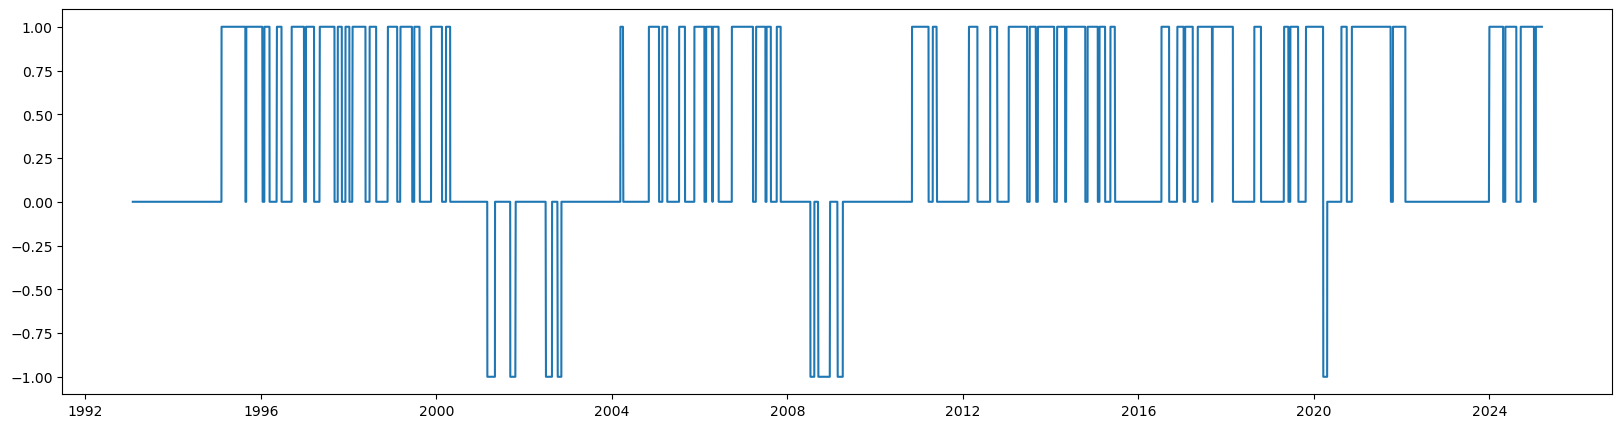

# END